# Linear Algebra for Machine Learning
### Interactive Notebook for AI/ML Interview Preparation

Covers matrix operations, eigendecomposition, SVD, projections, and their ML connections.

📺 **Video Lecture:** [https://youtu.be/YpckH7F5vj0](https://youtu.be/YpckH7F5vj0)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Matrix Operations

In [3]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print('A ='); print(A)
print(f'\nTranspose A^T ='); print(A.T)
print(f'\nA × B ='); print(A @ B)
print(f'\nInverse A⁻¹ ='); print(np.linalg.inv(A))
print(f'\nDeterminant |A| = {np.linalg.det(A):.1f}')
print(f'Trace tr(A) = {np.trace(A)}')
print(f'Rank = {np.linalg.matrix_rank(A)}')
print(f'\nVerify A × A⁻¹ = I:'); print(np.round(A @ np.linalg.inv(A), 10))

A =
[[1 2]
 [3 4]]

Transpose A^T =
[[1 3]
 [2 4]]

A × B =
[[19 22]
 [43 50]]

Inverse A⁻¹ =
[[-2.   1. ]
 [ 1.5 -0.5]]

Determinant |A| = -2.0
Trace tr(A) = 5
Rank = 2

Verify A × A⁻¹ = I:
[[1. 0.]
 [0. 1.]]


---
## 2. Eigenvalues and Eigenvectors

Av = λv: eigenvectors define directions preserved by transformation; eigenvalues scale them.

Eigenvalues: [3. 2.]
Eigenvectors (columns):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]


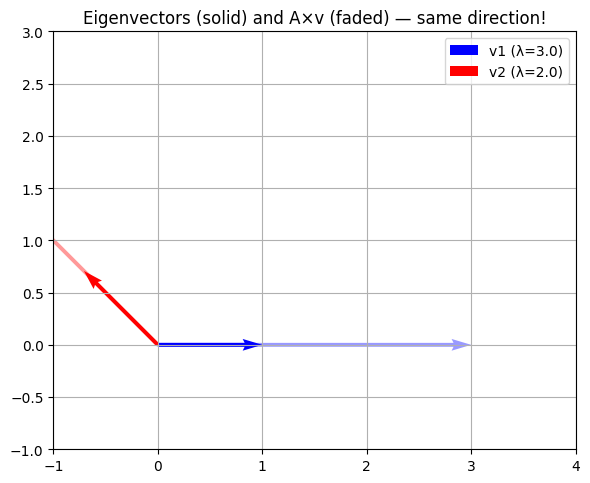

In [4]:
A = np.array([[3, 1], [0, 2]])
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f'Eigenvalues: {eigenvalues}')
print(f'Eigenvectors (columns):\n{eigenvectors}')

# Visualize: A transforms eigenvectors, only scaling them
fig, ax = plt.subplots(figsize=(6, 6))
origin = np.array([0, 0])
colors = ['blue', 'red']
for i in range(2):
    v = eigenvectors[:, i]
    Av = A @ v
    ax.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1,
             color=colors[i], label=f'v{i+1} (λ={eigenvalues[i]:.1f})', linewidth=2)
    ax.quiver(*origin, *Av, angles='xy', scale_units='xy', scale=1,
             color=colors[i], alpha=0.4, linestyle='--', linewidth=2)
ax.set_xlim(-1, 4); ax.set_ylim(-1, 3)
ax.set_aspect('equal'); ax.grid(True); ax.legend()
ax.set_title('Eigenvectors (solid) and A×v (faded) — same direction!')
plt.tight_layout()
plt.show()

---
## 3. Singular Value Decomposition (SVD)

A = UΣV^T — factorizes any matrix into rotation × scaling × rotation.

In [5]:
# SVD and low-rank approximation
np.random.seed(42)
A = np.random.rand(5, 4)
U, s, Vt = np.linalg.svd(A, full_matrices=False)

print(f'Original shape: {A.shape}')
print(f'U: {U.shape}, Σ: {s.shape}, V^T: {Vt.shape}')
print(f'Singular values: {np.round(s, 3)}')

# Rank-2 approximation
k = 2
A_approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
error = np.linalg.norm(A - A_approx, 'fro')
print(f'\nRank-{k} approximation error: {error:.4f}')
print(f'Energy captured: {sum(s[:k]**2)/sum(s**2):.1%}')

Original shape: (5, 4)
U: (5, 4), Σ: (4,), V^T: (4, 4)
Singular values: [2.199 0.798 0.671 0.261]

Rank-2 approximation error: 0.7198
Energy captured: 91.3%


---
## 4. PCA as Eigendecomposition

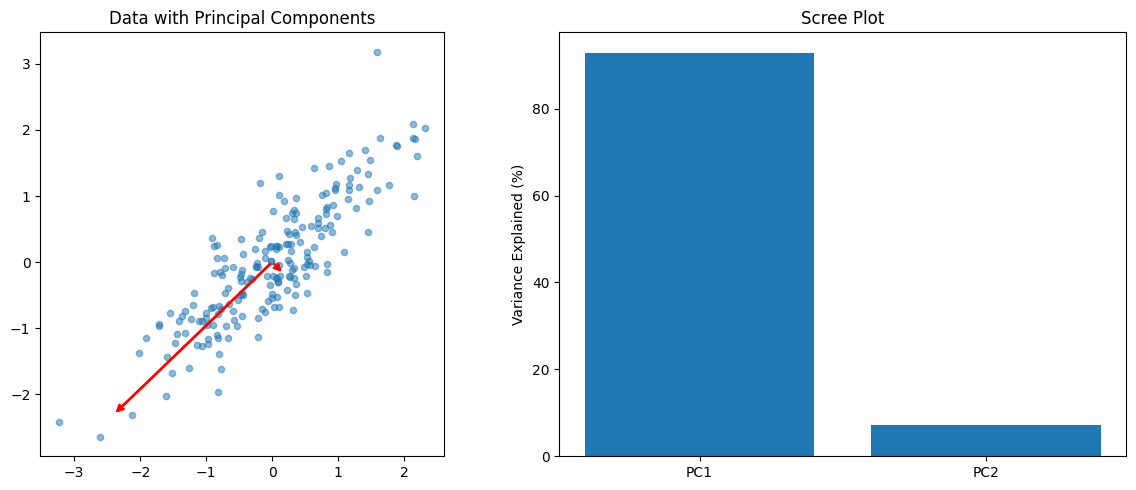

PC1 explains 92.9% of variance


In [6]:
# PCA from scratch using eigendecomposition of covariance matrix
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=200, centers=1, n_features=2, random_state=42)
X[:, 1] = X[:, 0] * 0.8 + np.random.normal(0, 0.5, 200)  # correlated

# Center data
X_centered = X - X.mean(axis=0)
cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by largest eigenvalue
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Project onto first PC
pc1 = X_centered @ eigenvectors[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, s=20)
for i in range(2):
    v = eigenvectors[:, i] * eigenvalues[i] * 2
    axes[0].annotate('', xy=v, xytext=[0,0],
                     arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].set_title('Data with Principal Components')
axes[0].set_aspect('equal')

axes[1].bar([1, 2], eigenvalues / eigenvalues.sum() * 100)
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['PC1', 'PC2'])
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Scree Plot')
plt.tight_layout()
plt.show()
print(f'PC1 explains {eigenvalues[0]/eigenvalues.sum()*100:.1f}% of variance')

---
## 5. Solving Linear Systems & Positive Definiteness

In [7]:
# Solve Ax = b
A = np.array([[2, 1], [1, 3]])
b = np.array([5, 7])
x = np.linalg.solve(A, b)
print(f'Solution x = {x}')
print(f'Verify: A @ x = {A @ x}  (should equal b = {b})')

# Check positive definiteness
evals = np.linalg.eigvalsh(A)
print(f'\nEigenvalues of A: {evals}')
print(f'Positive definite? {np.all(evals > 0)}')
print(f'Condition number: {np.linalg.cond(A):.2f} (lower = more stable)')

Solution x = [1.6 1.8]
Verify: A @ x = [5. 7.]  (should equal b = [5 7])

Eigenvalues of A: [1.38196601 3.61803399]
Positive definite? True
Condition number: 2.62 (lower = more stable)


---
## Key Interview Takeaways

1. **Eigendecomposition** — fundamental to PCA, spectral methods, and understanding transformations
2. **SVD** — generalizes eigen-decomposition to non-square matrices; powers LSA, recommender systems
3. **PCA = eigen-decomposition of covariance matrix** — the most direct ML connection
4. **Positive definite** — all eigenvalues > 0; covariance matrices are always positive semi-definite
5. **Condition number** — high values mean numerical instability (matrix is nearly singular)

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>